# Análisis Exploratorio de Datos (EDA)
## Motor de búsqueda semántica de ofertas laborales

**Proyecto Integrador 1 — Ingeniería de Sistemas**

### Objetivo del notebook

Realizar un análisis exploratorio del *Job Description Dataset* con el fin de:

- comprender la estructura y calidad de los datos;
- identificar variables relevantes para la búsqueda semántica;
- detectar valores faltantes y registros duplicados;
- estudiar la distribución de variables categóricas, numéricas y temporales;
- analizar específicamente las variables textuales que posteriormente podrán utilizarse para generar embeddings mediante Sentence Transformers;
- obtener conclusiones que orienten las siguientes etapas de limpieza, representación semántica y construcción del motor de búsqueda.

## 1. Importación de librerías

Se utilizarán únicamente las librerías solicitadas para esta etapa: **Pandas, NumPy y Matplotlib**.

- **Pandas:** carga, transformación y análisis tabular.
- **NumPy:** operaciones numéricas y apoyo estadístico.
- **Matplotlib:** visualización de distribuciones y resultados.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

### Configuracion de variables de entorno

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
!kaggle datasets download -d ravindrasinghrana/job-description-dataset -p /data/raw --unzip

## 2. Carga del dataset

In [ ]:
RUTA_DATASET = "/data/raw/job_descriptions.csv"

df = pd.read_csv(RUTA_DATASET)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


## 3. Dimensiones del dataset

Se consultan el número de filas y columnas.

In [22]:
filas, columnas = df.shape

print(f"Número de registros: {filas:,}")
print(f"Número de variables: {columnas}")

Número de registros: 1,615,940
Número de variables: 23


## 4. Primeras observaciones

Se muestran las primeras filas para observar cómo están estructurados los registros.

In [ ]:
df.head()

## 5. Información general y tipos de datos

`info()` permite revisar:

- nombre de cada variable;
- cantidad de valores no nulos;
- tipo de dato;
- consumo aproximado de memoria.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  object 
 2   Qualifications    1615940 non-null  object 
 3   Salary Range      1615940 non-null  object 
 4   location          1615940 non-null  object 
 5   Country           1615940 non-null  object 
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  object 
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  object 
 11  Preference        1615940 non-null  object 
 12  Contact Person    1615940 non-null  object 
 13  Contact           1615940 non-null  object 
 14  Job Title         1615940 non-null  object 
 15  Role              1615940 non-null  object 
 16  

## 6. Estadísticas descriptivas

Se muestran estadísticas de las variables numéricas.

In [25]:
df.describe()

,Job Id,latitude,longitude,Company Size
count,1.615940e+06,1.615940e+06,1.615940e+06,1.615940e+06
mean,1.548935e+15,1.937743e+01,1.639926e+01,7.370467e+04
std,8.946722e+14,2.355690e+01,7.066762e+01,3.529886e+04
min,1.817948e+11,-4.090060e+01,-1.751982e+02,1.264600e+04
25%,7.740508e+14,5.152100e+00,-1.531010e+01,4.311400e+04
50%,1.547858e+15,1.807080e+01,1.914510e+01,7.363300e+04
75%,2.323729e+15,3.907420e+01,4.757690e+01,1.043000e+05
max,3.099618e+15,7.170690e+01,1.780650e+02,1.348340e+05


## 7. Resumen de valores faltantes

Se calcula la cantidad y porcentaje de valores nulos por variable.

In [26]:
faltantes = df.isna().sum()
porcentaje_faltantes = (faltantes / len(df)) * 100

resumen_faltantes = pd.DataFrame({
    "Valores faltantes": faltantes,
    "Porcentaje (%)": porcentaje_faltantes
}).sort_values("Valores faltantes", ascending=False)

resumen_faltantes[resumen_faltantes["Valores faltantes"] > 0]

,Valores faltantes,Porcentaje (%)
Company Profile,5478,0.338998


## 8. Visualización de valores faltantes

El gráfico permite identificar rápidamente qué variables requieren atención.

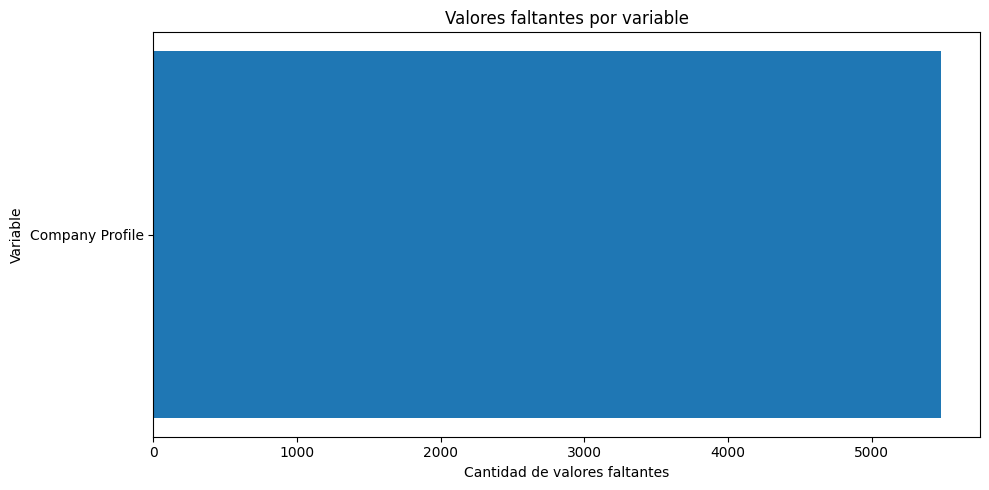

In [27]:
faltantes_grafico = faltantes[faltantes > 0].sort_values()

plt.figure(figsize=(10, 5))
plt.barh(faltantes_grafico.index, faltantes_grafico.values)
plt.title("Valores faltantes por variable")
plt.xlabel("Cantidad de valores faltantes")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 9. Registros duplicados

Se comprueba cuántas filas completas están repetidas.

In [28]:
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados:,}")
print(f"Porcentaje de duplicados: {(duplicados / len(df)) * 100:.4f}%")

Registros duplicados: 0
Porcentaje de duplicados: 0.0000%


## 10. Análisis de identificadores

`Job Id` debería funcionar como identificador de las ofertas.

Se comprueba cuántos valores son únicos.

In [29]:
job_id_unicos = df["Job Id"].nunique()
job_id_duplicados = df["Job Id"].duplicated().sum()

print(f"Job Id únicos: {job_id_unicos:,}")
print(f"Job Id repetidos: {job_id_duplicados:,}")

Job Id únicos: 1,615,940
Job Id repetidos: 0


## 11. Variables relevantes para la búsqueda semántica

El proyecto busca relacionar consultas de usuarios con contenido de ofertas. Por ello, las variables textuales tienen especial interés.

### Candidatas principales

- `Job Title`
- `Role`
- `Qualifications`
- `skills`
- `Responsibilities`
- `Job Description`

### Variables principalmente estructuradas

- `Experience`
- `Salary Range`
- `location`
- `Country`
- `Work Type`
- `Company Size`
- `Preference`

**Interpretación:** las variables textuales pueden combinarse posteriormente para construir una representación semántica de cada oferta. Las variables estructuradas pueden conservarse para filtros y presentación de resultados.


## 12. Distribución por tipo de trabajo

Se analiza `Work Type`.

In [30]:
work_type = df["Work Type"].value_counts(dropna=False)

print(work_type)

Work Type
Part-Time    324044
Temporary    323439
Contract     323131
Intern       323090
Full-Time    322236
Name: count, dtype: int64


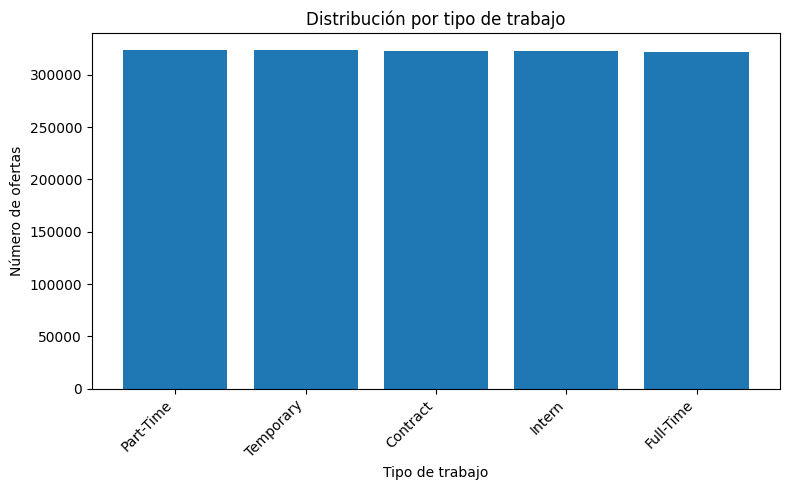

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(work_type.index.astype(str), work_type.values)
plt.title("Distribución por tipo de trabajo")
plt.xlabel("Tipo de trabajo")
plt.ylabel("Número de ofertas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 13. Distribución de experiencia requerida

Se estudia la variable `Experience`.

In [32]:
experience = df["Experience"].value_counts()

print(experience)

Experience
5 to 8 Years     34120
5 to 12 Years    34056
5 to 9 Years     34020
3 to 13 Years    33915
3 to 15 Years    33878
2 to 9 Years     33862
3 to 8 Years     33854
1 to 11 Years    33820
3 to 12 Years    33805
1 to 10 Years    33793
4 to 11 Years    33776
3 to 9 Years     33744
4 to 14 Years    33744
4 to 12 Years    33737
2 to 8 Years     33736
4 to 15 Years    33732
0 to 11 Years    33729
1 to 13 Years    33724
4 to 8 Years     33715
2 to 13 Years    33712
1 to 9 Years     33710
1 to 12 Years    33703
0 to 15 Years    33693
1 to 15 Years    33681
1 to 8 Years     33680
3 to 11 Years    33663
0 to 14 Years    33650
5 to 14 Years    33629
4 to 10 Years    33621
0 to 9 Years     33601
5 to 11 Years    33600
5 to 13 Years    33592
2 to 14 Years    33584
0 to 8 Years     33575
1 to 14 Years    33570
2 to 10 Years    33532
3 to 14 Years    33530
0 to 12 Years    33523
0 to 13 Years    33516
2 to 12 Years    33512
2 to 11 Years    33488
5 to 15 Years    33477
5 to 10 Years    33471


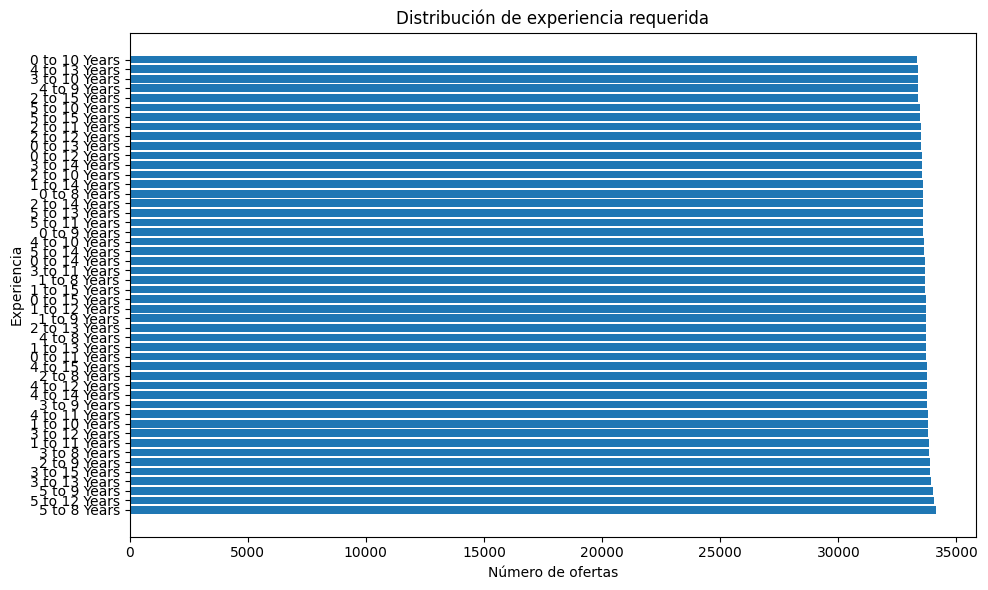

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(experience.index.astype(str), experience.values)
plt.title("Distribución de experiencia requerida")
plt.xlabel("Número de ofertas")
plt.ylabel("Experiencia")
plt.tight_layout()
plt.show()

## 14. Países con mayor cantidad de ofertas

Se muestran los 15 países con más registros.

In [34]:
top_paises = df["Country"].value_counts().head(15)

print(top_paises)

Country
Malta            7723
Venezuela, RB    7694
Somalia          7689
Sierra Leone     7656
Sri Lanka        7649
Vietnam          7649
Azerbaijan       7643
San Marino       7638
Turkmenistan     7633
Rwanda           7630
Sweden           7626
North Korea      7618
Mexico           7617
Fiji             7612
Liberia          7605
Name: count, dtype: int64


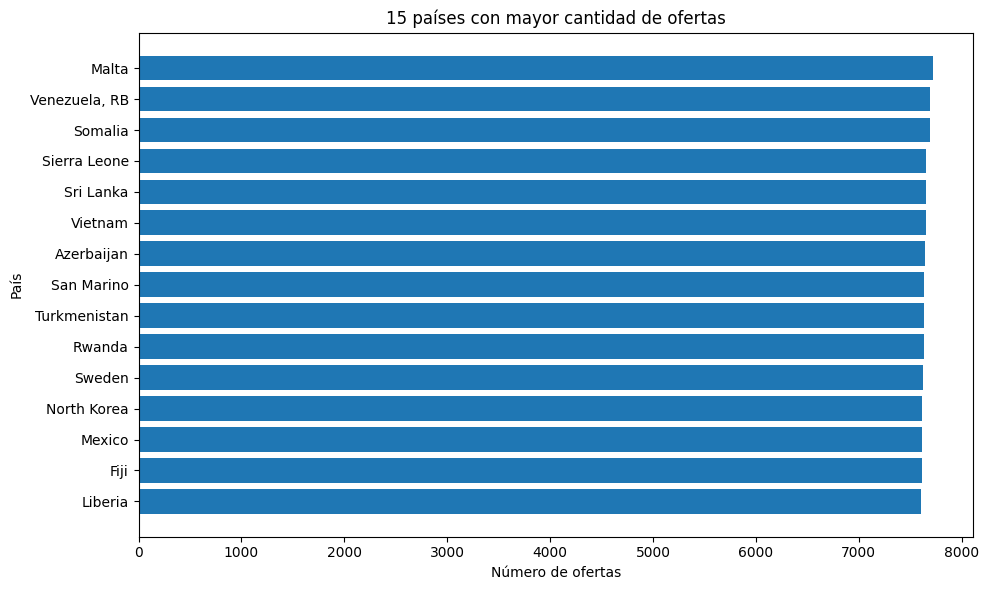

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(top_paises.index[::-1], top_paises.values[::-1])
plt.title("15 países con mayor cantidad de ofertas")
plt.xlabel("Número de ofertas")
plt.ylabel("País")
plt.tight_layout()
plt.show()


## 15. Roles más frecuentes

Se analizan los 20 valores más frecuentes de `Role`.

In [36]:
top_roles = df["Role"].value_counts().head(20)

print(top_roles)

Role
Interaction Designer         20580
Network Administrator        17470
User Interface Designer      14036
Social Media Manager         13945
User Experience Designer     13935
Procurement Analyst          13757
Social Media Analyst         10659
Quality Assurance Analyst    10541
SEO Specialist               10512
Executive Assistant          10496
Database Administrator       10482
Procurement Manager          10407
Data Analyst                 10406
Backend Developer            10404
Demand Planner               10362
Office Manager               10361
Customer Success Manager     10308
Frontend Developer           10308
Retirement Planner           10305
Account Executive             7063
Name: count, dtype: int64


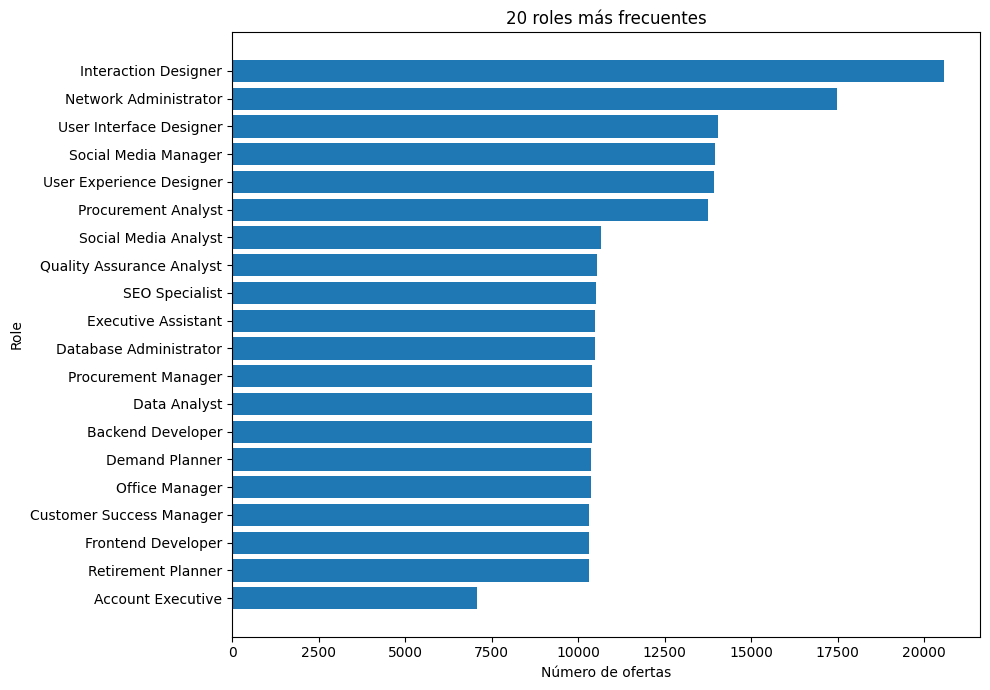

In [38]:
plt.figure(figsize=(10, 7))
plt.barh(top_roles.index[::-1], top_roles.values[::-1])
plt.title("20 roles más frecuentes")
plt.xlabel("Número de ofertas")
plt.ylabel("Role")
plt.tight_layout()
plt.show()

## 16. Títulos de cargo más frecuentes

Se muestran los 20 valores más frecuentes de `Job Title`.

**Interpretación:** comparar `Job Title` con `Role` ayuda a entender la variabilidad terminológica del dataset. Esta variabilidad es especialmente relevante para nuestro proyecto porque el buscador debe encontrar relaciones semánticas aunque las expresiones no sean idénticas.


In [39]:
top_titulos = df["Job Title"].value_counts().head(20)

print(top_titulos)

Job Title
UX/UI Designer                  48551
Digital Marketing Specialist    27975
Software Engineer               27630
Network Engineer                24393
Software Tester                 20945
Executive Assistant             20776
Procurement Manager             20734
Financial Advisor               20687
Sales Representative            17664
Social Media Manager            17613
Network Administrator           17581
Administrative Assistant        17484
Data Analyst                    17402
Event Planner                   17384
Procurement Specialist          17348
Purchasing Agent                17286
Systems Administrator           17281
HR Coordinator                  17260
Customer Support Specialist     17259
Legal Assistant                 14063
Name: count, dtype: int64


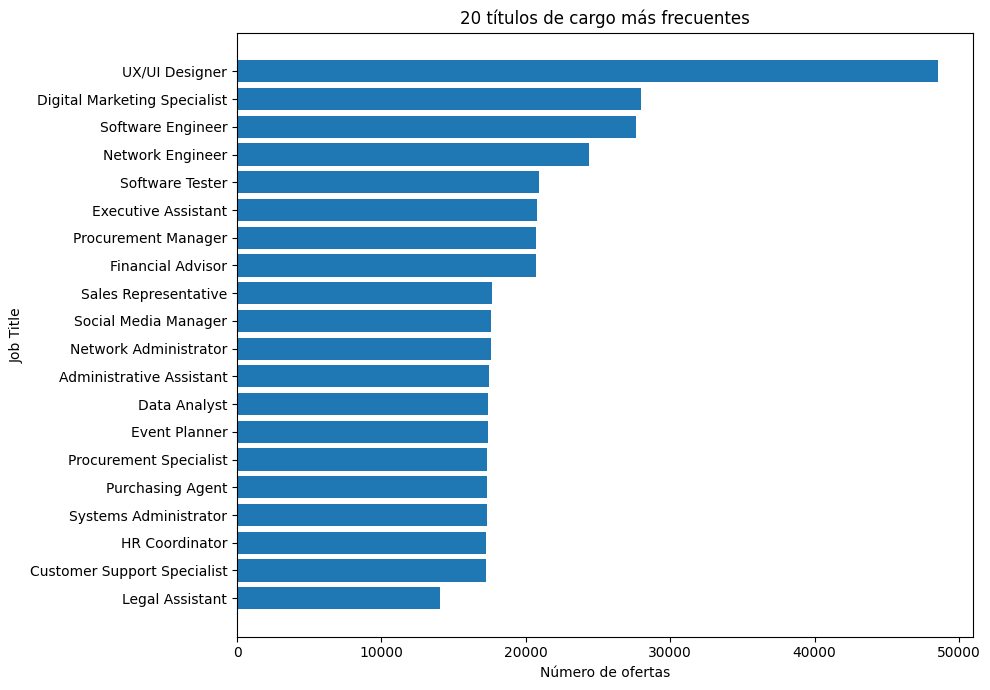

In [40]:
plt.figure(figsize=(10, 7))
plt.barh(top_titulos.index[::-1], top_titulos.values[::-1])
plt.title("20 títulos de cargo más frecuentes")
plt.xlabel("Número de ofertas")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

## 17. Tamaño de las empresas

Se analiza `Company Size`.

**Interpretación:** esta variable permite observar cómo se distribuyen las ofertas según el tamaño de la organización. Debido a que es numérica, también debemos comprobar sus valores mínimos y máximos para identificar posibles valores atípicos o codificaciones inesperadas.

In [41]:
company_size = df["Company Size"].describe()

print(company_size)

count    1.615940e+06
mean     7.370467e+04
std      3.529886e+04
min      1.264600e+04
25%      4.311400e+04
50%      7.363300e+04
75%      1.043000e+05
max      1.348340e+05
Name: Company Size, dtype: float64


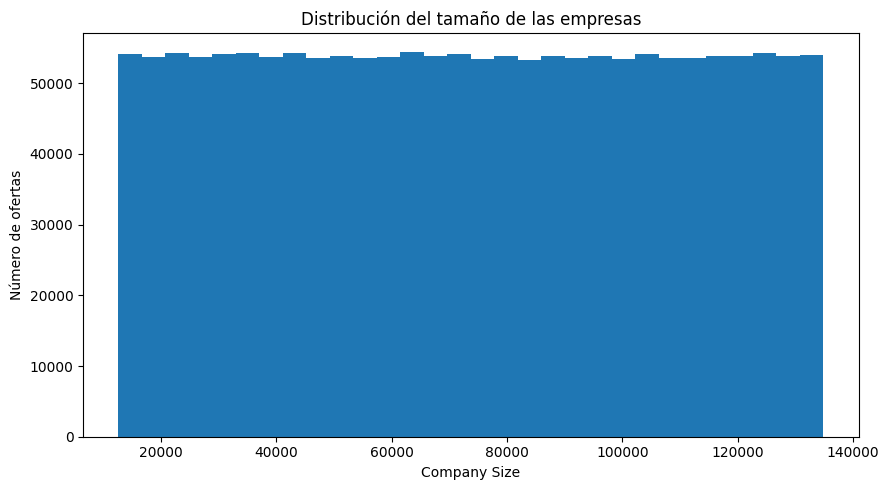

In [42]:
plt.figure(figsize=(9, 5))
plt.hist(df["Company Size"], bins=30)
plt.title("Distribución del tamaño de las empresas")
plt.xlabel("Company Size")
plt.ylabel("Número de ofertas")
plt.tight_layout()
plt.show()

## 18. Análisis temporal de las ofertas

`Job Posting Date` está almacenada inicialmente como texto, por lo que se transforma a formato fecha.

**Interpretación:** esto permite analizar la distribución temporal de las publicaciones. Es importante validar si existen fechas inválidas o si el periodo está concentrado en determinados años.


In [43]:
df["Job Posting Date"] = pd.to_datetime(
    df["Job Posting Date"],
    errors="coerce"
)

print(df["Job Posting Date"].isna().sum())
print(df["Job Posting Date"].min())
print(df["Job Posting Date"].max())

0
2021-09-15 00:00:00
2023-09-15 00:00:00


In [44]:
publicaciones_por_anio = df["Job Posting Date"].dt.year.value_counts().sort_index()

print(publicaciones_por_anio)

Job Posting Date
2021    238944
2022    806158
2023    570838
Name: count, dtype: int64


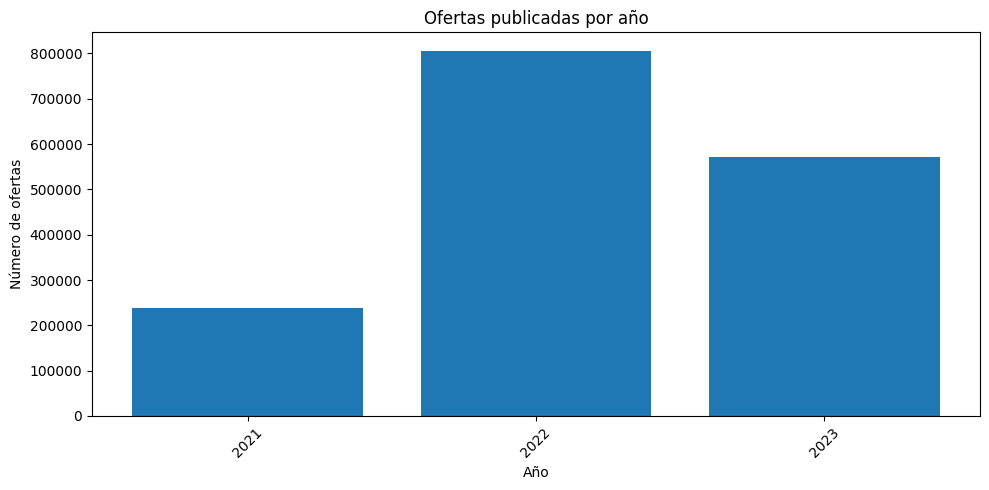

In [45]:
plt.figure(figsize=(10, 5))
plt.bar(publicaciones_por_anio.index.astype(str), publicaciones_por_anio.values)
plt.title("Ofertas publicadas por año")
plt.xlabel("Año")
plt.ylabel("Número de ofertas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 19. Análisis de variables textuales

Las variables textuales son fundamentales para el buscador semántico.

Se revisará:

- cantidad de caracteres;
- textos vacíos;
- textos extremadamente cortos;
- distribución de longitudes.

Para estas métricas se utilizará una **muestra aleatoria**, evitando crear simultáneamente muchas Series adicionales sobre 1,6 millones de textos.

**Interpretación:** este análisis permitirá decidir qué tan necesario será limpiar los textos antes de generar embeddings.


In [46]:
COLUMNAS_TEXTO = [
    "Job Title",
    "Role",
    "Qualifications",
    "skills",
    "Responsibilities",
    "Job Description"
]

COLUMNAS_TEXTO

['Job Title',
 'Role',
 'Qualifications',
 'skills',
 'Responsibilities',
 'Job Description']

## 20. Muestreo para el análisis textual

Se seleccionan hasta 100.000 registros de forma reproducible.

**Interpretación:** una muestra suficientemente grande permite observar la distribución de las variables textuales sin exigir el mismo costo computacional que procesar repetidamente todo el dataset.

In [47]:
TAMANO_MUESTRA = min(100_000, len(df))
muestra = df.sample(n=TAMANO_MUESTRA, random_state=42)

print(f"Tamaño de la muestra: {len(muestra):,}")

Tamaño de la muestra: 100,000


## 21. Longitud de los campos textuales

Se calcula la longitud en caracteres de cada campo.

**Interpretación:** campos demasiado cortos pueden aportar poca información semántica, mientras que campos excesivamente largos pueden requerir decisiones de truncamiento o selección de contenido dependiendo del modelo utilizado posteriormente.

In [48]:
longitudes = pd.DataFrame(index=muestra.index)

for columna in COLUMNAS_TEXTO:
    longitudes[columna] = muestra[columna].fillna("").astype(str).str.len()

longitudes.describe().T

,count,mean,std,min,25%,50%,75%,max
Job Title,100000.0,17.34064,4.666451,7.0,14.0,17.0,19.0,35.0
Role,100000.0,20.70565,5.397144,8.0,17.0,20.0,24.0,40.0
Qualifications,100000.0,3.90158,1.375395,2.0,3.0,3.0,5.0,6.0
skills,100000.0,139.16735,58.798191,49.0,92.0,125.0,172.0,300.0
Responsibilities,100000.0,185.93121,23.002929,121.0,171.0,187.0,203.0,249.0
Job Description,100000.0,185.44788,51.695862,81.0,156.0,178.0,213.0,430.0


## 22. Textos vacíos o sin contenido

Se calcula qué proporción de la muestra no contiene información en cada variable textual.

**Interpretación:** las variables con una proporción elevada de textos vacíos podrían aportar poco al embedding y requerir tratamiento especial. En cambio, si la mayoría de registros contienen texto, dichas variables serán buenas candidatas para construir la representación semántica.


In [49]:
vacios_texto = (longitudes == 0).sum()
porcentaje_vacios = (vacios_texto / len(muestra)) * 100

resumen_texto = pd.DataFrame({
    "Vacíos": vacios_texto,
    "Porcentaje (%)": porcentaje_vacios
}).sort_values("Porcentaje (%)", ascending=False)

resumen_texto

,Vacíos,Porcentaje (%)
Job Title,0,0.0
Role,0,0.0
Qualifications,0,0.0
skills,0,0.0
Responsibilities,0,0.0
Job Description,0,0.0


## 23. Distribución de la longitud de Job Description

Se utiliza un histograma sobre la muestra.

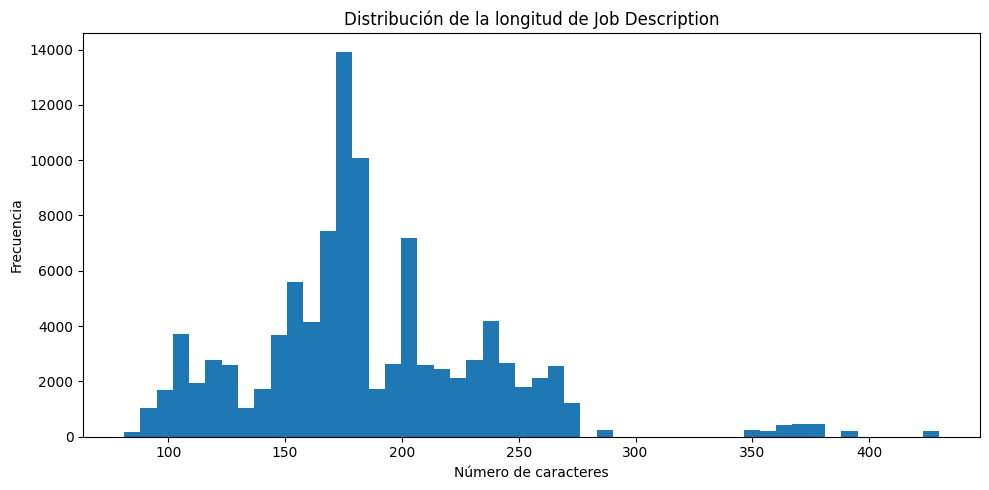

In [50]:
plt.figure(figsize=(10, 5))
plt.hist(longitudes["Job Description"], bins=50)
plt.title("Distribución de la longitud de Job Description")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 24. Distribución de la longitud de Skills

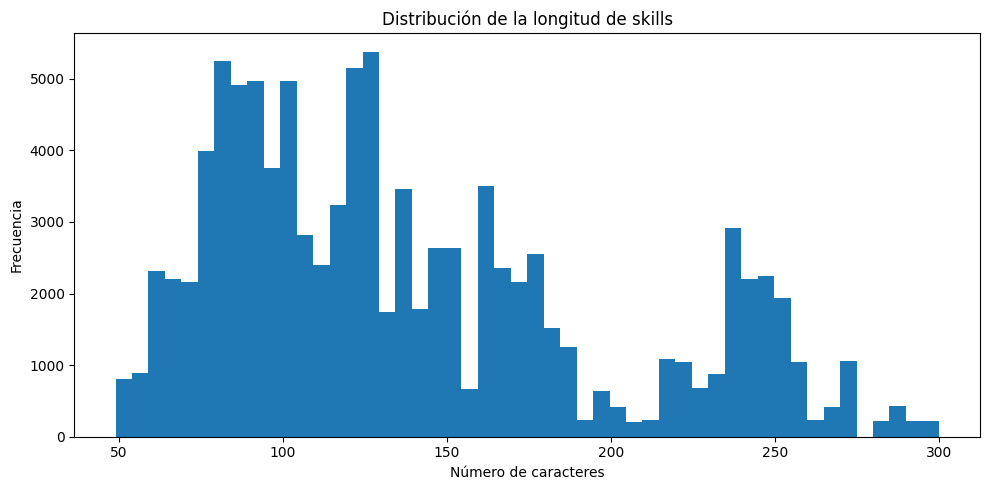

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(longitudes["skills"], bins=50)
plt.title("Distribución de la longitud de skills")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 25. Distribución de la longitud de Responsibilities

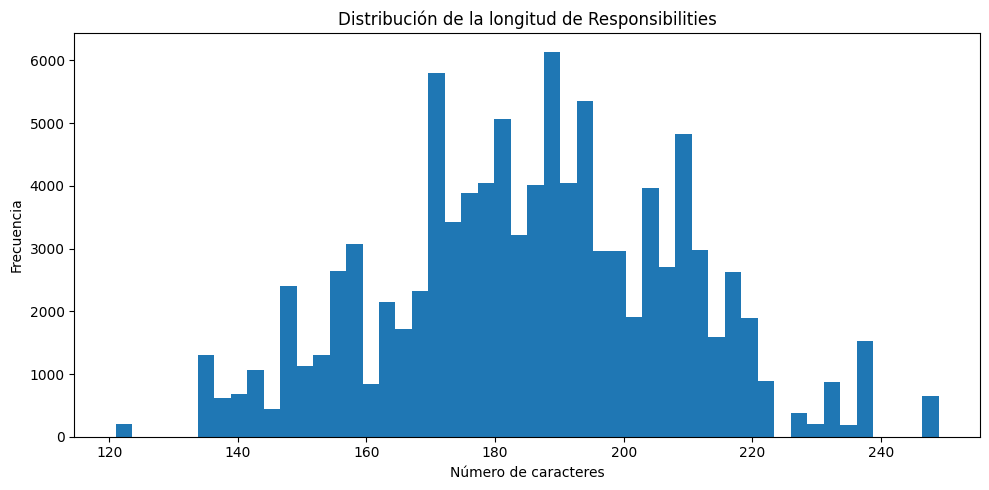

In [52]:
plt.figure(figsize=(10, 5))
plt.hist(longitudes["Responsibilities"], bins=50)
plt.title("Distribución de la longitud de Responsibilities")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 26. Estadísticas de las variables textuales

Se presenta una tabla comparativa de longitud.

In [53]:
resumen_longitudes = pd.DataFrame({
    "Promedio": longitudes.mean(),
    "Mediana": longitudes.median(),
    "Mínimo": longitudes.min(),
    "Máximo": longitudes.max()
}).sort_values("Promedio", ascending=False)

resumen_longitudes

,Promedio,Mediana,Mínimo,Máximo
Responsibilities,185.93121,187.0,121,249
Job Description,185.44788,178.0,81,430
skills,139.16735,125.0,49,300
Role,20.70565,20.0,8,40
Job Title,17.34064,17.0,7,35
Qualifications,3.90158,3.0,2,6


## 27. Distribución del salario

`Salary Range` está almacenada como texto porque normalmente representa un rango y no un valor numérico simple.

In [54]:
df["Salary Range"].value_counts().head(15)

,count
Salary Range,
$59K-$88K,3043
$58K-$101K,3038
$62K-$82K,3033
$61K-$106K,3025
$61K-$112K,3015
$62K-$107K,3003
$64K-$83K,3003
$64K-$120K,3003
$62K-$84K,3000


## 28. Preferencia laboral

Se estudia `Preference`, que puede aportar información adicional sobre condiciones o preferencias de la vacante.

In [56]:
preference = df["Preference"].value_counts()

print(preference)

Preference
Male      539167
Both      538437
Female    538336
Name: count, dtype: int64


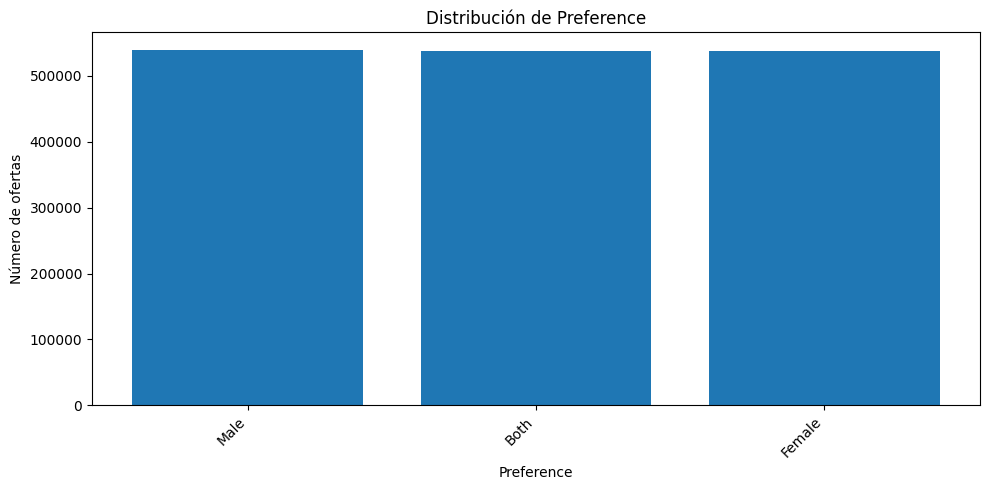

In [57]:
plt.figure(figsize=(10, 5))
plt.bar(preference.index.astype(str), preference.values)
plt.title("Distribución de Preference")
plt.xlabel("Preference")
plt.ylabel("Número de ofertas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 29. Matriz de correlación de variables numéricas

Se analiza la relación entre las variables numéricas disponibles.

In [58]:
columnas_numericas = df.select_dtypes(include=[np.number]).columns

correlacion = df[columnas_numericas].corr()

correlacion

,Job Id,latitude,longitude,Company Size
Job Id,1.000000,0.000468,-0.000009,-0.002323
latitude,0.000468,1.000000,0.021753,0.000149
longitude,-0.000009,0.021753,1.000000,-0.000871
Company Size,-0.002323,0.000149,-0.000871,1.000000


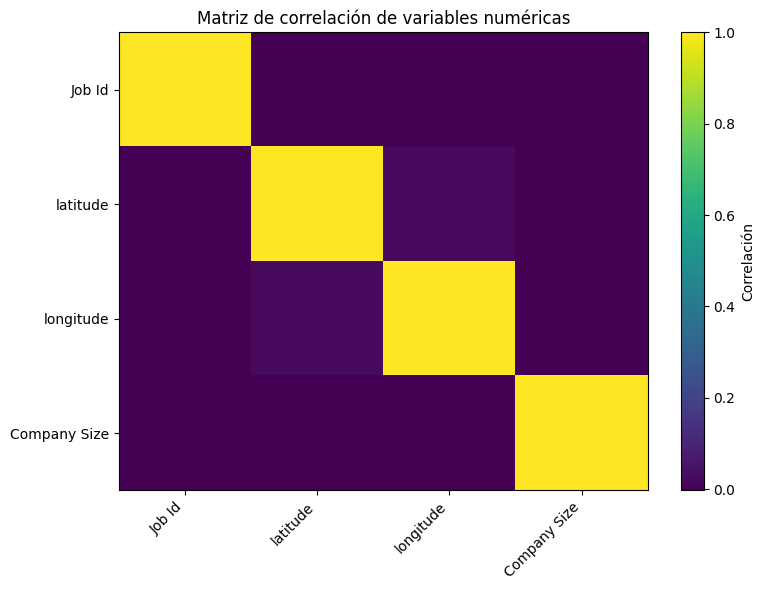

In [59]:
plt.figure(figsize=(8, 6))
plt.imshow(correlacion, aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlacion.index)),
    correlacion.index
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


## 30. Exploración de la información geográfica

Se revisan los rangos de `latitude` y `longitude`.

In [60]:
print("Latitud:")
print(df["latitude"].describe())

print("\nLongitud:")
print(df["longitude"].describe())


Latitud:
count    1.615940e+06
mean     1.937743e+01
std      2.355690e+01
min     -4.090060e+01
25%      5.152100e+00
50%      1.807080e+01
75%      3.907420e+01
max      7.170690e+01
Name: latitude, dtype: float64

Longitud:
count    1.615940e+06
mean     1.639926e+01
std      7.066762e+01
min     -1.751982e+02
25%     -1.531010e+01
50%      1.914510e+01
75%      4.757690e+01
max      1.780650e+02
Name: longitude, dtype: float64


## 31. Identificación de columnas candidatas para embeddings

Con base en el objetivo del proyecto, se propone inicialmente separar:

### Texto semántico
- `Job Title`
- `Role`
- `Qualifications`
- `skills`
- `Responsibilities`
- `Job Description`

### Filtros / metadatos
- `Experience`
- `Salary Range`
- `location`
- `Country`
- `Work Type`
- `Company Size`
- `Preference`
- `Job Posting Date`

### Identificación y presentación
- `Job Id`
- `Company`
- `Job Portal`

In [61]:
columnas_embedding = [
    "Job Title",
    "Role",
    "Qualifications",
    "skills",
    "Responsibilities",
    "Job Description"
]

columnas_filtros = [
    "Experience",
    "Salary Range",
    "location",
    "Country",
    "Work Type",
    "Company Size",
    "Preference",
    "Job Posting Date"
]

print("Columnas propuestas para embeddings:")
for columna in columnas_embedding:
    print("-", columna)

print("\nColumnas propuestas como filtros/metadatos:")
for columna in columnas_filtros:
    print("-", columna)


Columnas propuestas para embeddings:
- Job Title
- Role
- Qualifications
- skills
- Responsibilities
- Job Description

Columnas propuestas como filtros/metadatos:
- Experience
- Salary Range
- location
- Country
- Work Type
- Company Size
- Preference
- Job Posting Date


# 32. Conclusiones del análisis exploratorio

1. **Magnitud del dataset:** número total de ofertas y variables.
    - El número total de ofertas de trabajo o registros es de 1,615,940.  
    - El dataset está conformado por un número total de 23 variables.  
2. **Calidad:** valores faltantes y duplicados encontrados.
    - En cuanto a valores faltantes, solo se encontraron 5,478 valores nulos en la variable "Company Profile".  
    - La cantidad de valores faltantes en "Company Profile" representa el 0.338998% de todo el dataset.  
    - El dataset tiene una excelente calidad respecto a registros duplicados, encontrándose 0 filas repetidas (0.0000%).  
    - El identificador de la oferta ("Job Id") funciona correctamente, validándose 1,615,940 valores únicos y 0 repetidos.  
3. **Distribución:** principales países, roles, tipos de trabajo y niveles de experiencia.
    - Los principales paises son Malta, Venezuela y RB
    - Los principales roles son Interaction Designer, Network Administrator y User interface Designer
    - Los principales tipos de trabajo son Part-Time, Temporary y Contract
    - Los principales niveles de experiencia son 5-8, 5-12 y 5-9
4. **Temporalidad:** periodo cubierto por las publicaciones.
    - El dataset posee una columna denominada "Job Posting Date" clasificada inicialmente con el tipo de dato "object".  
    - El periodo exacto data desde eñ 15 de Septiembre de 2021 hasta el 15 de Septiembre de 2023
5. **Contenido textual:** longitud y presencia de información en las variables que alimentarán el buscador.
    - Se validó la presencia de información en las siguientes variables que alimentarán el motor de búsqueda: "Job Title", "Role", "Qualifications", "skills", "Responsibilities" y "Job Description".
6. **Diseño preliminar:** variables candidatas para embeddings frente a filtros y metadatos.
    - Las variables candidatas principales para generar embeddings y construir la representación semántica son netamente textuales: "Job Title", "Role", "Qualifications", "skills", "Responsibilities" y "Job Description".  
    - Las variables principalmente estructuradas que se conservarán como filtros y metadatos para presentar resultados son: "Experience", "Salary Range", "location", "Country", "Work Type", "Company Size" y "Preference".  

In [62]:
print("RESUMEN AUTOMÁTICO DEL DATASET")
print("-" * 50)
print(f"Registros: {len(df):,}")
print(f"Variables: {df.shape[1]}")
print(f"Duplicados completos: {df.duplicated().sum():,}")
print(f"Columnas con faltantes: {(df.isna().sum() > 0).sum()}")
print(f"Valores faltantes en Company Profile: {df['Company Profile'].isna().sum():,}")
print(f"Fecha mínima: {df['Job Posting Date'].min()}")
print(f"Fecha máxima: {df['Job Posting Date'].max()}")
print(f"Promedio de caracteres en Job Description (muestra): {longitudes['Job Description'].mean():.2f}")
print(f"Mediana de caracteres en Job Description (muestra): {longitudes['Job Description'].median():.2f}")

RESUMEN AUTOMÁTICO DEL DATASET
--------------------------------------------------
Registros: 1,615,940
Variables: 23
Duplicados completos: 0
Columnas con faltantes: 1
Valores faltantes en Company Profile: 5,478
Fecha mínima: 2021-09-15 00:00:00
Fecha máxima: 2023-09-15 00:00:00
Promedio de caracteres en Job Description (muestra): 185.45
Mediana de caracteres en Job Description (muestra): 178.00
